In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import shap
from sklearn.calibration import calibration_curve
import warnings
warnings.filterwarnings('ignore')

print("Libraries loaded successfully")

Libraries loaded successfully


In [2]:
# Paths
DATA_PATH  = r'C:\Users\Hp\Desktop\readmission\data\\'
MODEL_PATH = r'C:\Users\Hp\Desktop\readmission\outputs\\'

# Load data
train = pd.read_csv(DATA_PATH + 'train.csv')
test  = pd.read_csv(DATA_PATH + 'test.csv')

# Features
FEATURES = ['los', 'age', 'gender_male', 'high_risk_discharge',
            'prior_admissions', 'num_medications', 'num_diagnoses',
            'num_abnormal_labs']

X_train = train[FEATURES]
y_train = train['readmitted_30d']
X_test  = test[FEATURES]
y_test  = test['readmitted_30d']

# Load saved model and threshold
xgb_model      = joblib.load(MODEL_PATH + 'xgb_model.pkl')
best_threshold = joblib.load(MODEL_PATH + 'threshold.pkl')

print("✅ Data loaded")
print("✅ Model loaded")
print(f"✅ Threshold loaded: {best_threshold}")

✅ Data loaded
✅ Model loaded
✅ Threshold loaded: 0.25000000000000006


In [3]:
# Paths
DATA_PATH  = r'C:\Users\Hp\Desktop\readmission\data\\'
MODEL_PATH = r'C:\Users\Hp\Desktop\readmission\outputs\\'

# Load data
train = pd.read_csv(DATA_PATH + 'train.csv')
test  = pd.read_csv(DATA_PATH + 'test.csv')

# Features
FEATURES = ['los', 'age', 'gender_male', 'high_risk_discharge',
            'prior_admissions', 'num_medications', 'num_diagnoses',
            'num_abnormal_labs']

X_train = train[FEATURES]
y_train = train['readmitted_30d']
X_test  = test[FEATURES]
y_test  = test['readmitted_30d']

# Load saved model and threshold
xgb_model      = joblib.load(MODEL_PATH + 'xgb_model.pkl')
best_threshold = joblib.load(MODEL_PATH + 'threshold.pkl')

print("✅ Data loaded")
print("✅ Model loaded")
print(f"✅ Threshold loaded: {best_threshold}")

✅ Data loaded
✅ Model loaded
✅ Threshold loaded: 0.25000000000000006


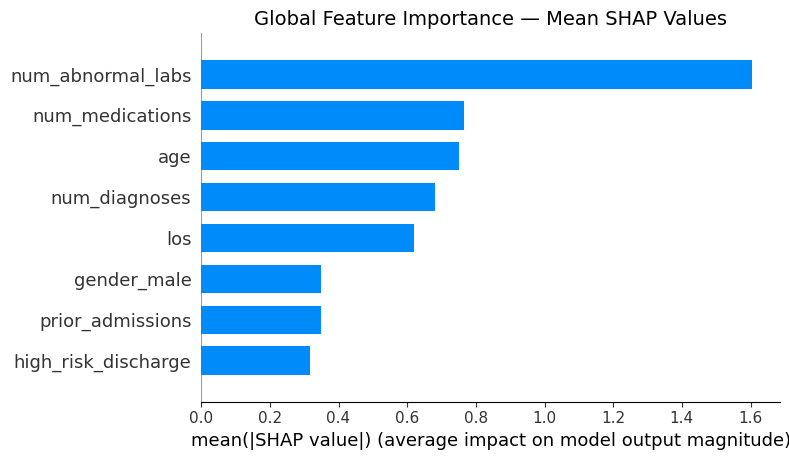

✅ Saved shap_global.png


In [4]:
# Create SHAP explainer
explainer = shap.TreeExplainer(xgb_model)

# Calculate SHAP values for test data
shap_values = explainer.shap_values(X_test)

# Plot global feature importance
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test, plot_type="bar", show=False)
plt.title("Global Feature Importance — Mean SHAP Values", fontsize=14)
plt.tight_layout()
plt.savefig(MODEL_PATH + 'shap_global.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved shap_global.png")

Highest risk patient index : 32
Risk score                 : 0.755

Patient features:
los                     6.0
age                    53.0
gender_male             1.0
high_risk_discharge     1.0
prior_admissions        9.0
num_medications        58.0
num_diagnoses          17.0
num_abnormal_labs      73.0
Name: 32, dtype: float64


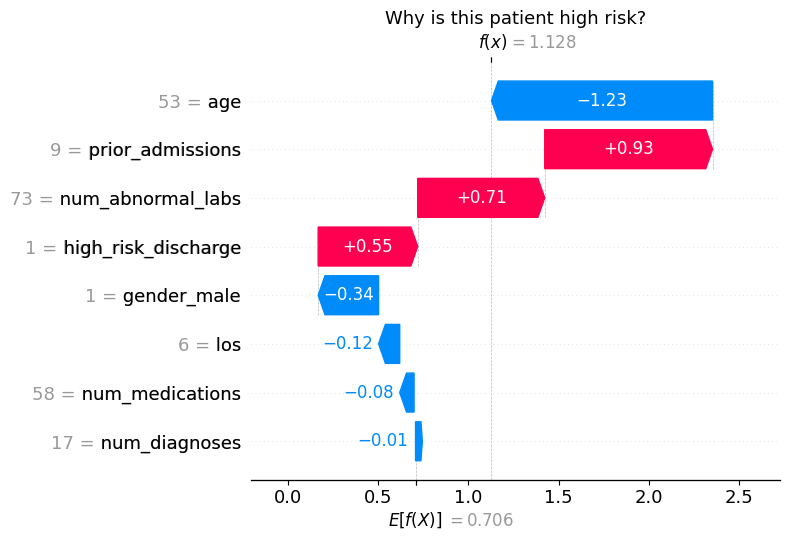

✅ Saved shap_waterfall.png


In [9]:
# Pick the highest risk patient from test set
xgb_probs = xgb_model.predict_proba(X_test)[:, 1]
highest_risk_idx = np.argmax(xgb_probs)

print(f"Highest risk patient index : {highest_risk_idx}")
print(f"Risk score                 : {xgb_probs[highest_risk_idx]:.3f}")
print(f"\nPatient features:")
print(X_test.iloc[highest_risk_idx])

# Waterfall plot for this patient
shap.plots.waterfall(
    shap.Explanation(
        values      = shap_values[highest_risk_idx],
        base_values = explainer.expected_value,
        data        = X_test.iloc[highest_risk_idx].values,
        feature_names = FEATURES
    ),
    show=False
)
plt.title("Why is this patient high risk?", fontsize=13)
plt.tight_layout()
plt.savefig(MODEL_PATH + 'shap_waterfall.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved shap_waterfall.png")

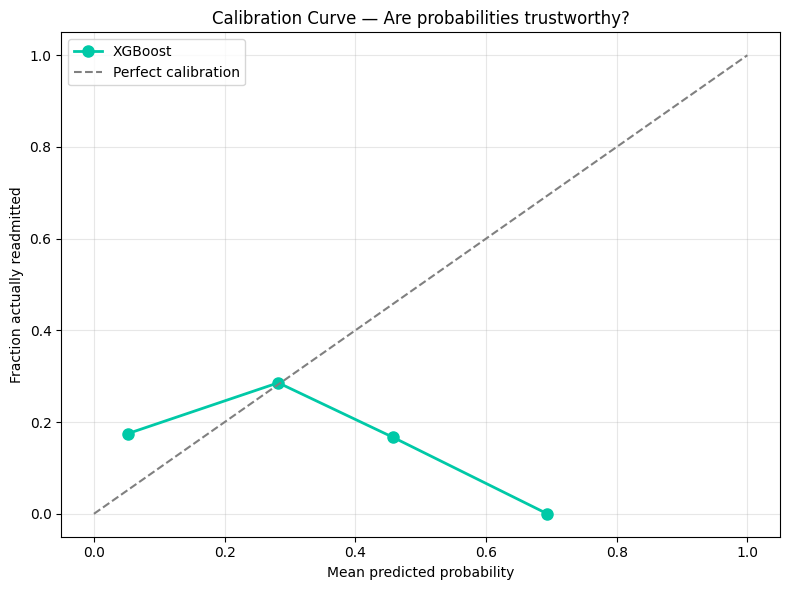

✅ Saved calibration.png


In [10]:
from sklearn.calibration import calibration_curve

# Get probabilities
xgb_probs = xgb_model.predict_proba(X_test)[:, 1]

# Calculate calibration curve
fraction_pos, mean_pred = calibration_curve(y_test, xgb_probs, n_bins=5)

# Plot
plt.figure(figsize=(8, 6))
plt.plot(mean_pred, fraction_pos, 'o-', color='#00C9A7', linewidth=2, 
         markersize=8, label='XGBoost')
plt.plot([0, 1], [0, 1], '--', color='gray', label='Perfect calibration')
plt.xlabel('Mean predicted probability')
plt.ylabel('Fraction actually readmitted')
plt.title('Calibration Curve — Are probabilities trustworthy?')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(MODEL_PATH + 'calibration.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved calibration.png")

In [ ]:
/